170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 276ms/step - accuracy: 0.0953 - loss: 2.6571
Test Accuracy: 0.09529999643564224
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 283ms/step


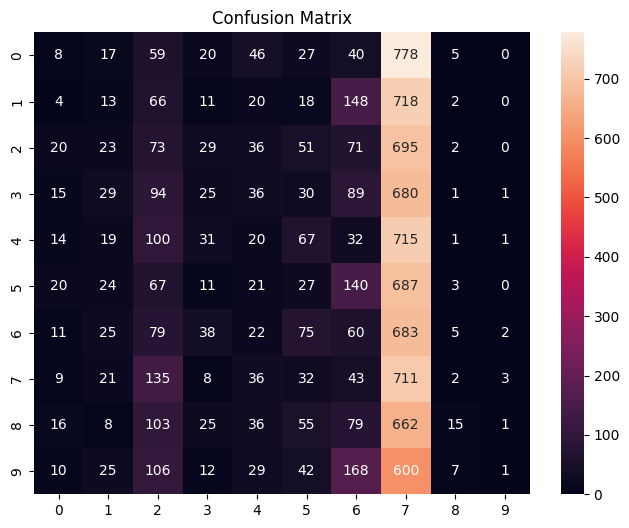

              precision    recall  f1-score   support

           0       0.06      0.01      0.01      1000
           1       0.06      0.01      0.02      1000
           2       0.08      0.07      0.08      1000
           3       0.12      0.03      0.04      1000
           4       0.07      0.02      0.03      1000
           5       0.06      0.03      0.04      1000
           6       0.07      0.06      0.06      1000
           7       0.10      0.71      0.18      1000
           8       0.35      0.01      0.03      1000
           9       0.11      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.11      0.10      0.05     10000
weighted avg       0.11      0.10      0.05     10000



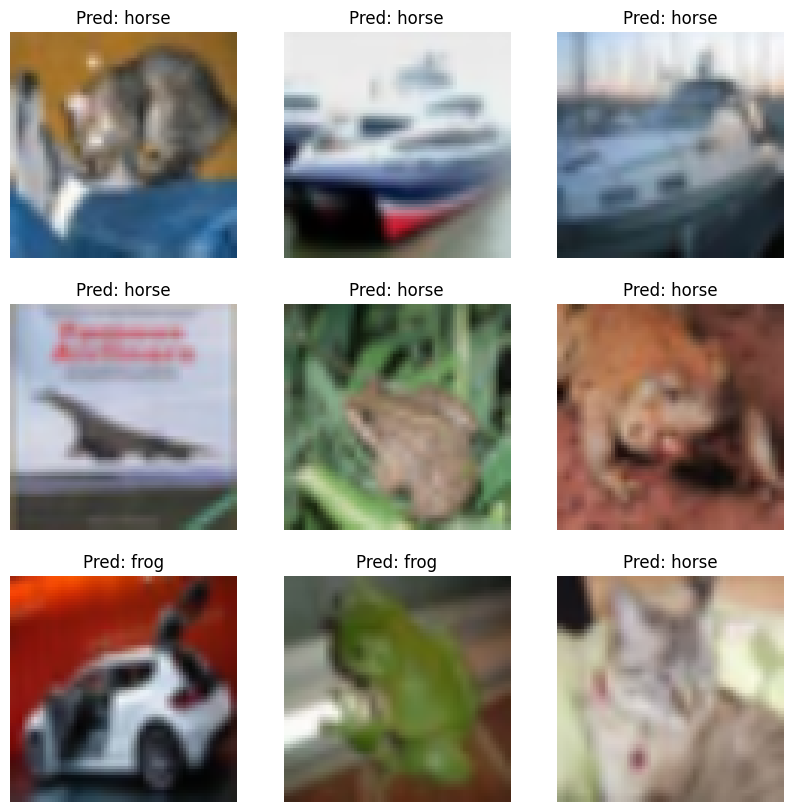

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

SEED_VALUE = 42
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape)
print(X_test.shape)

X_train = tf.image.resize(X_train, (75,75)) / 255.0
X_test = tf.image.resize(X_test, (75,75)) / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

base_model = InceptionV3(weights='imagenet',
                         include_top=False,
                         input_shape=(75,75,3))

base_model.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.axis('off')
    plt.title("Pred: " + class_names[y_pred[i]])

plt.show()
